(38, 6)
(38,)
[10 11 15 16 20 22 26 29]
[ 1.06281938 -0.20001318 -0.21093179 -0.19981314  3.75928901 -1.00132013
  0.89584582  1.59368505]
KRR_MAE:0.504,1.337,KRR_RMSE:0.71,1.885


d:\py\Anaconda3\lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
d:\py\Anaconda3\lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


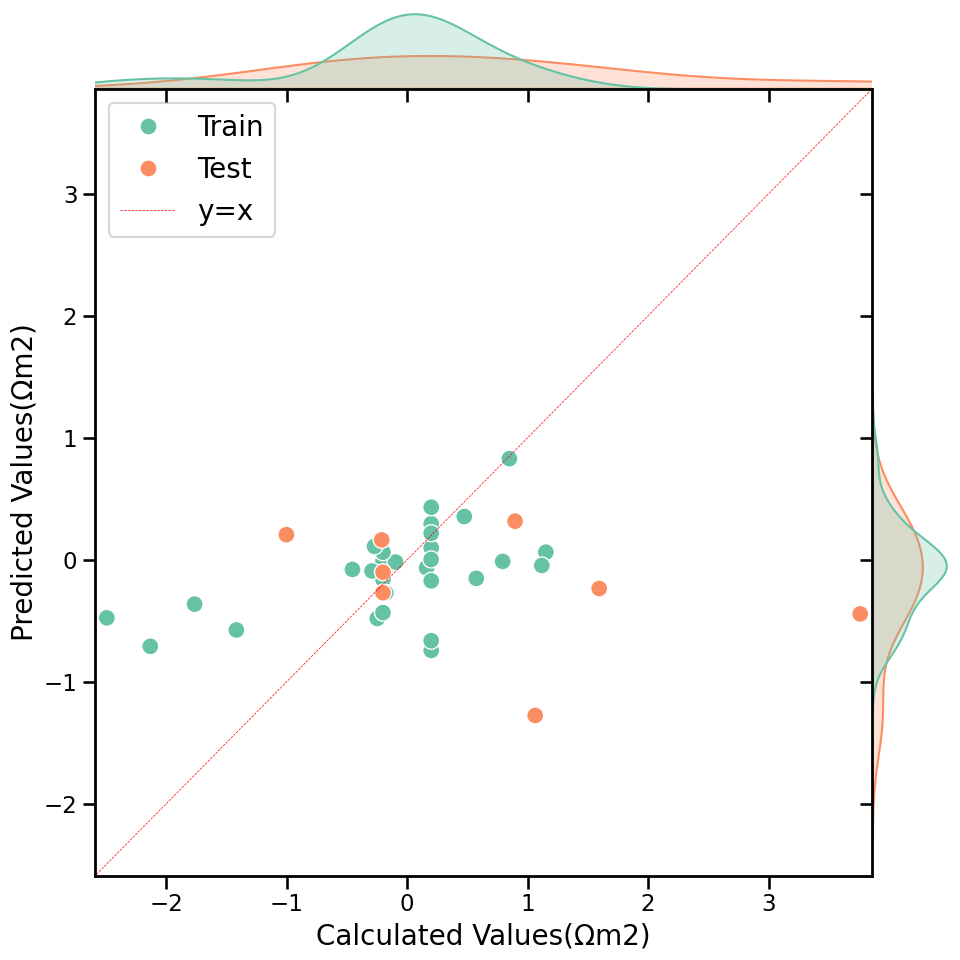

[ 2 25 30 31 32 33 35 37]
[ 0.57434489  0.792747   -0.24755229  0.20028699 -0.17740325 -0.20000179
 -0.2704728   1.11773318]
KRR_MAE:0.645,0.535,KRR_RMSE:1.045,0.658


d:\py\Anaconda3\lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
d:\py\Anaconda3\lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


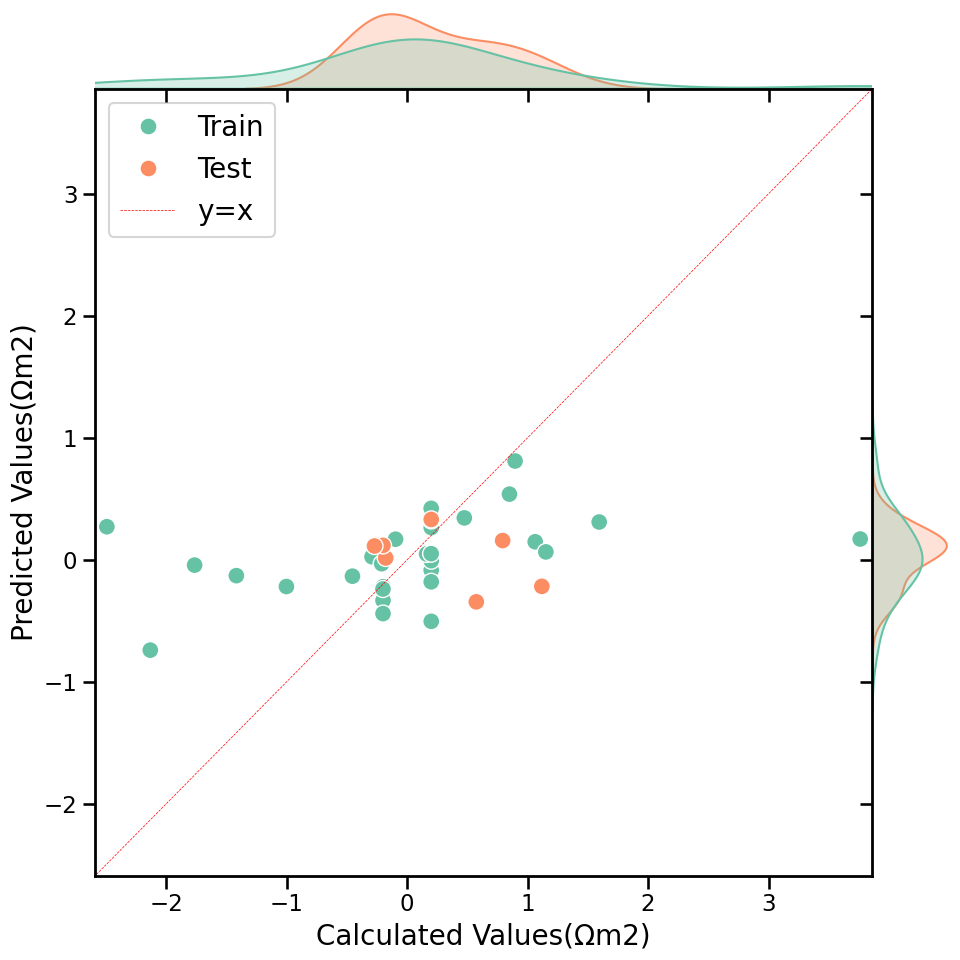

[ 5  7  8 13 14 17 28 34]
[ 0.20016217 -0.20039527  0.19974944  0.19957022  0.84905918 -2.13076292
  0.19979064 -0.20037561]
KRR_MAE:0.67,0.611,KRR_RMSE:1.048,0.889


d:\py\Anaconda3\lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
d:\py\Anaconda3\lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


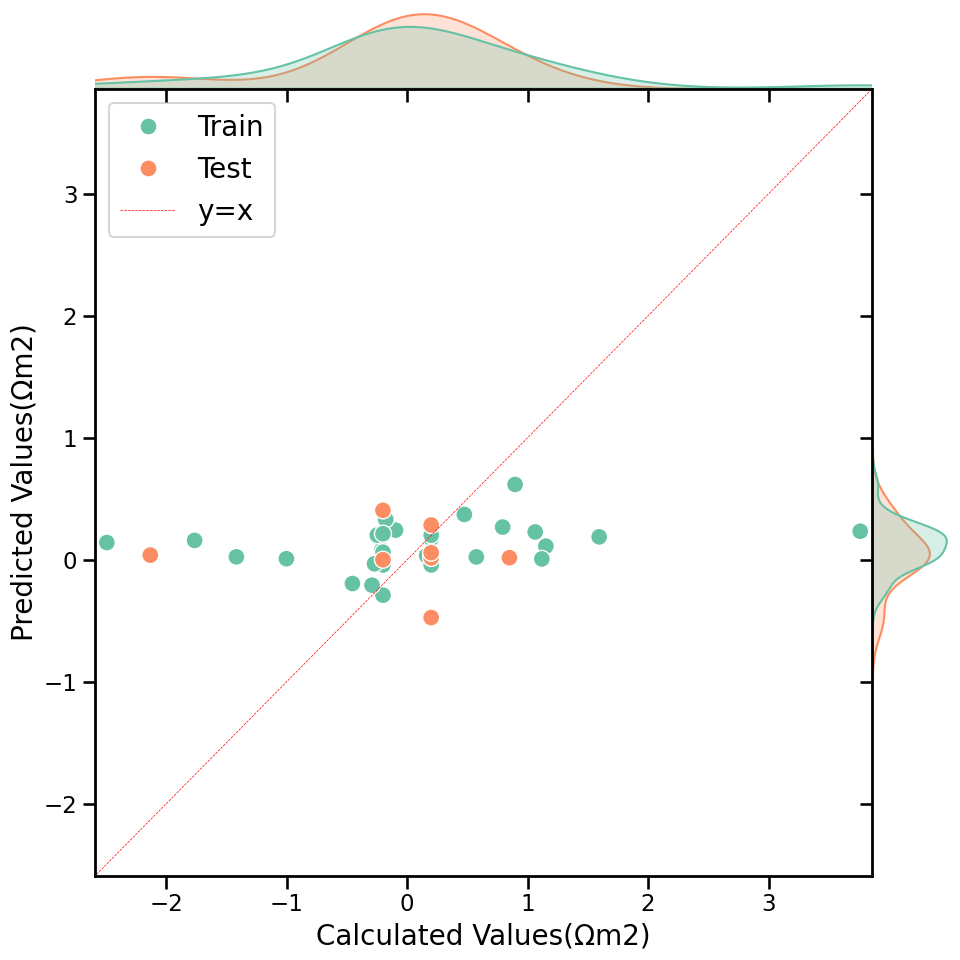

[ 1  4  6 12 23 24 27]
[-0.19992495 -1.41650527  0.20037648 -0.2912556  -2.49118142  1.15120905
 -0.09592984]
KRR_MAE:0.547,1.572,KRR_RMSE:0.803,1.894


d:\py\Anaconda3\lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
d:\py\Anaconda3\lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


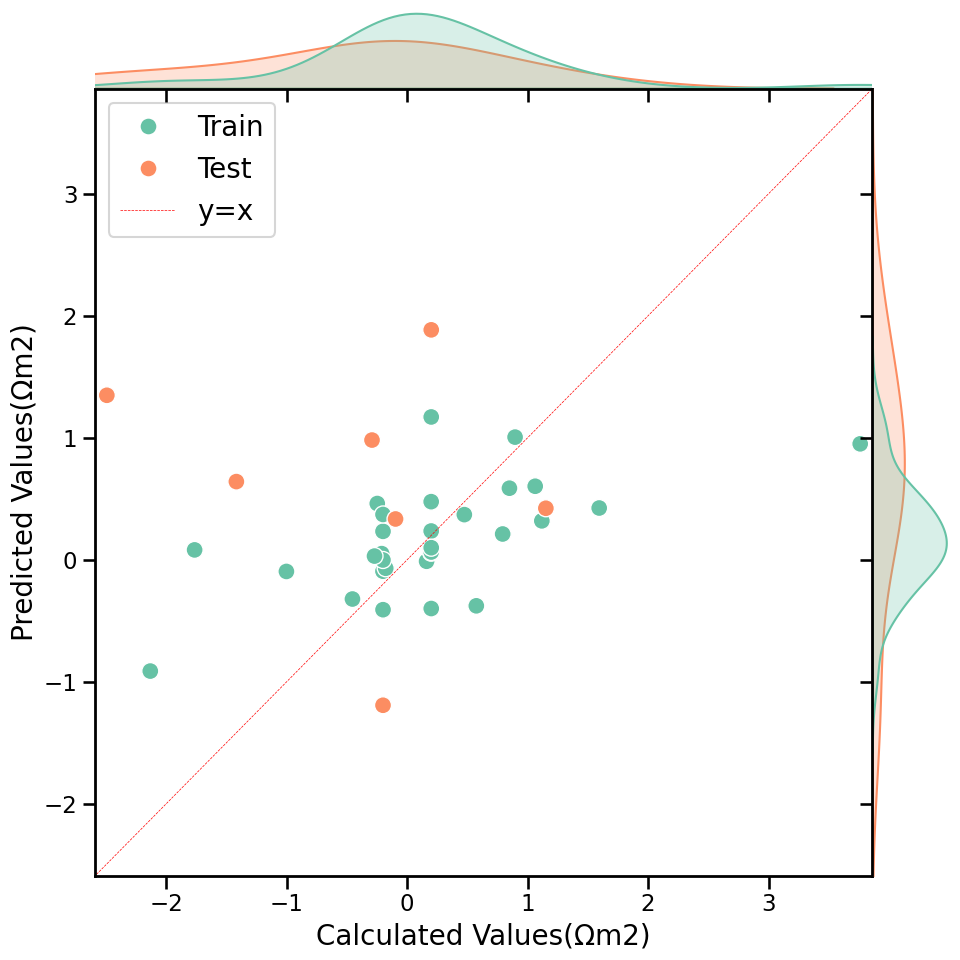

[ 0  3  9 18 19 21 36]
[ 0.47486197  0.19991335  0.16148337  0.20027913  0.20018678 -1.76305717
 -0.45340517]
KRR_MAE:0.619,1.106,KRR_RMSE:0.953,1.539


d:\py\Anaconda3\lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
d:\py\Anaconda3\lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


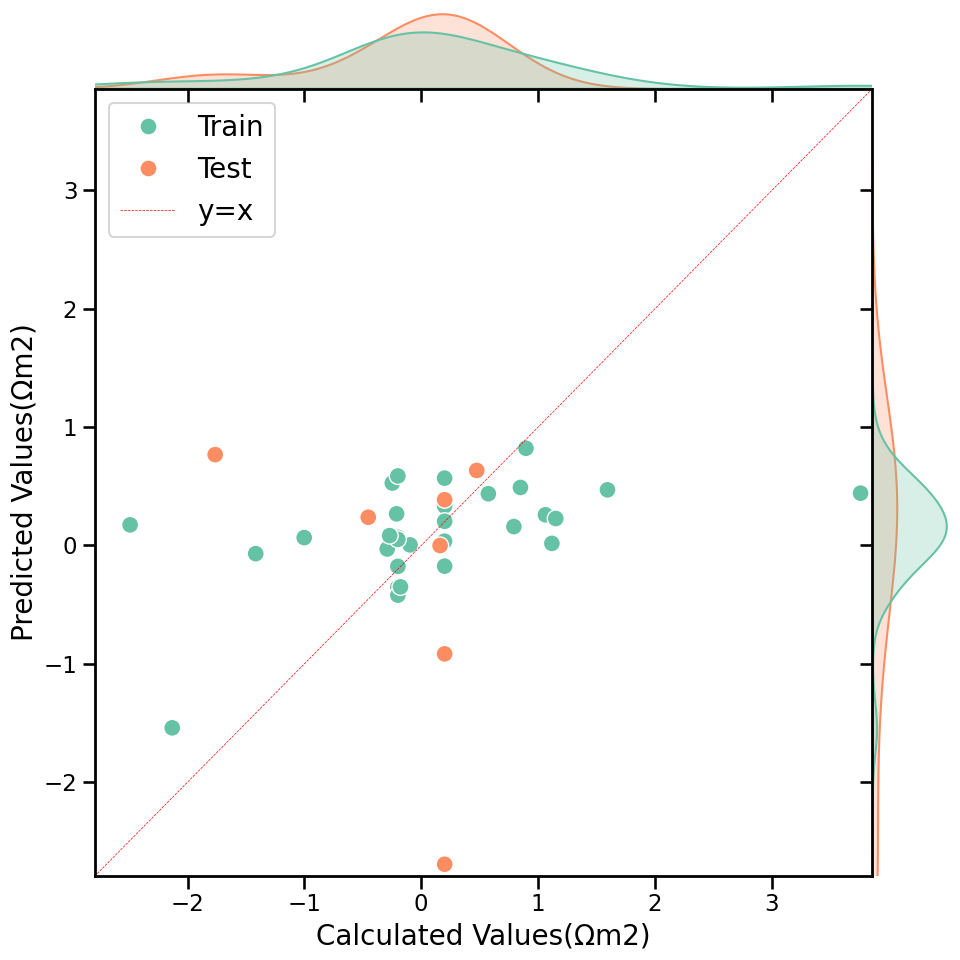

KRR_MAE:0.597+-0.062,1.032+-0.404,KRR_RMSE:0.912+-0.135,1.373+-0.511


['model.krr']

In [1]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
import time
import joblib
from scipy.stats import pearsonr
from modules import *
import sys
import math
import numpy as np
import matplotlib.pyplot as plt

File = 'y-y^(svr_fps)'
X,y= sub_data(File)
X,y= pre_data(X,y)
X=X[:38,:]
y=y[:38]
X=np.delete(X,[6],axis= 1)
print(X.shape)
print(y.shape)


R2_train_a=[]
R2_test_a=[]
MAE_train_a=[]
MAE_test_a=[]
MSE_train_a=[]
MSE_test_a=[]
RMSE_train_a=[]
RMSE_test_a=[]


ns=5
nr=1
kf = RepeatedKFold(n_splits=ns, n_repeats=nr, random_state=0)
for train_index, test_index in kf.split(X):
  X_train, y_train = X[train_index], y[train_index]
  X_test, y_test = X[test_index], y[test_index]
  print(test_index)
  print(y[test_index])
 # krr = KernelRidge(kernel='rbf', gamma=0.05, alpha=0.008)  #0.95-0.05比例中训练集有小到大的顺序得出的结论
  krr = KernelRidge(kernel='rbf', gamma=0.01, alpha=0.015)
  krr.fit(X_train, y_train)
  y_pre1=krr.predict(X_train)
  y_pre2=krr.predict(X_test)
  

  R2_train=round(krr.score(X_train, y_train),3)
  R2_test=round(krr.score(X_test, y_test),3)
  MAE_train = round(mean_absolute_error(y_train,y_pre1),3)
  MAE_test =  round(mean_absolute_error(y_test,y_pre2),3)
  MSE_train = round(mean_squared_error(y_train,y_pre1),3)
  MSE_test = round(mean_squared_error(y_test,y_pre2),3)
  RMSE_train = round(math.sqrt(MSE_train),3)
  RMSE_test = round(math.sqrt(MSE_test),3)
  R2_train_a += [R2_train]
  R2_test_a += [R2_test]
  MAE_train_a += [MAE_train]
  MAE_test_a += [MAE_test]
  MSE_train_a += [MSE_train]
  MSE_test_a += [MSE_test]
  RMSE_train_a += [RMSE_train]
  RMSE_test_a += [RMSE_test]
  print("KRR_MAE:%s,%s,KRR_RMSE:%s,%s" %(MAE_train,MAE_test,RMSE_train,RMSE_test))

  plot_train_test_results(y_train,y_test,y_pre1,y_pre2,output=True,fname='KRR')

R2_train_mean=round(np.mean(R2_train_a),3)
R2_train_std=round(np.std(R2_train_a),3)
R2_test_mean=round(np.mean(R2_test_a),3)
R2_test_std=round(np.std(R2_test_a),3)
MAE_train_mean=round(np.mean(MAE_train_a),3)
MAE_train_std=round(np.std(MAE_train_a),3)
MAE_test_mean=round(np.mean(MAE_test_a),3)
MAE_test_std=round(np.std(MAE_test_a),3)
MSE_train_mean=round(np.mean(MSE_train_a),3)
MSE_train_std=round(np.std(MSE_train_a),3)
MSE_test_mean=round(np.mean(MSE_test_a),3)
MSE_test_std=round(np.std(MSE_test_a),3)
RMSE_train_mean=round(np.mean(RMSE_train_a),3)
RMSE_train_std=round(np.std(RMSE_train_a),3)
RMSE_test_mean=round(np.mean(RMSE_test_a),3)
RMSE_test_std=round(np.std(RMSE_test_a),3)
print("KRR_MAE:%s+-%s,%s+-%s,KRR_RMSE:%s+-%s,%s+-%s" %(MAE_train_mean,MAE_train_std,MAE_test_mean,MAE_test_std,RMSE_train_mean,RMSE_train_std,RMSE_test_mean,RMSE_test_std))

# 保存模型
joblib.dump(krr, 'model.krr')

# 2. 最远点采样

(38, 6)
(38,)
[ 4  9 23 24 27 28 33 34]
KRR_fps_MAE:0.431,1.299,KRR__fps_RMSE:0.647,1.949


d:\py\Anaconda3\lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
d:\py\Anaconda3\lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


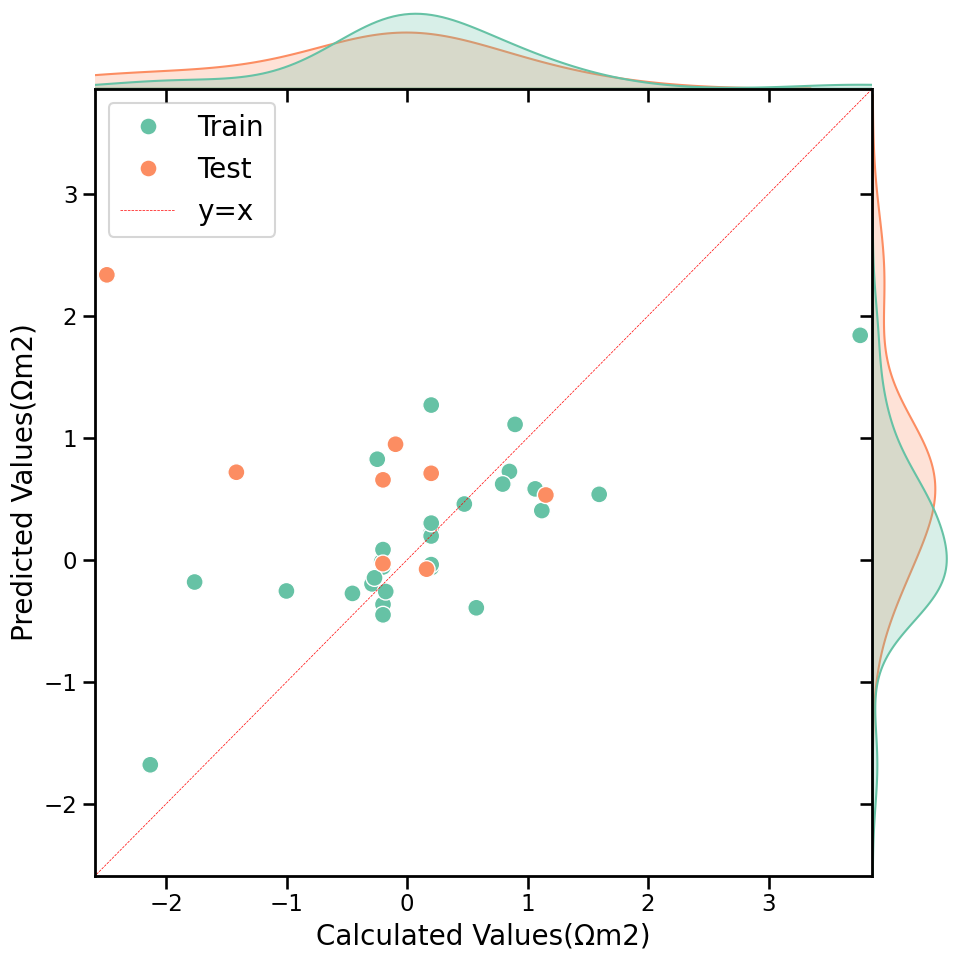

KRR__fps_MAE:0.431+-0.0,1.299+-0.0,KRR_fps_RMSE:0.647+-0.0,1.949+-0.0


['model.krr_fps']

In [2]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
import time
import joblib
from scipy.stats import pearsonr
from modules import *
import sys
import math
import numpy as np
import matplotlib.pyplot as plt

# 函数定义部分为最远点采样
def extdata(File,st='\t'):
    data1=open(File,'r+')
    X,y=[],[]
    for i, line in enumerate(data1):
        data=line.split(st)
        if len(data) < 5:
           continue
        else:

          for j in range(0,int(len(data))-1):
            X += [float(data[j])]
        y += [float(data[-1])]
        
    m=len(X)
    n=len(y)
    X=np.array(X).reshape(int(n),int(m/n))
    y=np.array(y)
    
    return X,y

## 02 sampleing the first point:
# centre: the center of points
# random: random sampling
def first_point(X,method='center',rand_seed=100):
    if method == 'center':
       # calculate the center of point sets
       fpoint=np.array([np.sum(X,axis=0)/X.shape[0]])
       item=[]
    elif method == 'random':
       # sampling via random bumber
      
       np.random.seed(int(rand_seed))
       item=np.random.randint(0,X.shape[0],size=1)
       fpoint=X[item]
    else:
       print('No other methods are adopted!')
    #distance_fp=np.sum((X-fpoint)**2,axis=1)
    return fpoint,item

## 03 calculating the distance between any two points
# criterion=['amount',3]
# criterion=['gra_dis',0.5]
def sampling(X,points,item,criterion=['gra_dis',1]):
    # distances bewteen points and first piont
    dis=np.sum((X-points)**2,axis=1)
    items=list(item) 
    center_dis=[]
    if criterion[0] == 'amount':
      for i in range(criterion[1]-1):
        # find the point farest from all sampling points
        new_point=X[np.argmax(dis)]
        points=np.vstack((points,[new_point]))
        items += [np.argmax(dis)]
        c1=np.array([np.sum(points[:-1,:],axis=0)/points.shape[0]])
        c2=np.array([np.sum(points,axis=0)/points.shape[0]])
        center_dis += [np.sum((c1-c2)**2,axis=1)]
        # find the minimun distance between every unsampling points and all sampling points 
        dis=np.minimum(dis,np.sum((X-new_point)**2,axis=1))
    elif criterion[0] == 'gra_dis':
      for j in range(X.shape[0]):     
        new_point=X[np.argmax(dis)]
        points=np.vstack((points,[new_point]))
        items += [np.argmax(dis)]
        # centers of sampling data this time and last time
        c1=np.array([np.sum(points[:-1,:],axis=0)/points.shape[0]])
        c2=np.array([np.sum(points,axis=0)/points.shape[0]])  
        center_dis += [np.sum((c1-c2)**2,axis=1)]
        # if the distance between centers of this and last times is smaller than the criterion 
        # or samping  all points, then finish!
        
        if (np.sum((c1-c2)**2,axis=1) <=float(criterion[1])**2) or (points.shape == X.shape): 
           #print(np.sum((c1-c2)**2,axis=1))
           print(f'{j+2} sampling Finish!')
           break
        else:
           #print(np.sum((c1-c2)**2,axis=1))
           dis=np.minimum(dis,np.sum((X-new_point)**2,axis=1))
    return points,items,np.sqrt(np.array(center_dis))

if __name__ == '__main__':

  File = '../data.4/error-1'
  X,y= sub_data(File)
  X,y= pre_data(X,y)
  X=X[:38,:]
  y=y[:38]

  X=np.delete(X,[6],axis= 1)
  print(X.shape)
  print(y.shape)
  method_1stp='random'
  fpoint,item=first_point(X,method=method_1stp)
  points,items,center_dis = sampling(X,fpoint,item,criterion=['amount',30]) 

    
R2_train_a=[]
R2_test_a=[]
MAE_train_a=[]
MAE_test_a=[]
MSE_train_a=[]
MSE_test_a=[]
RMSE_train_a=[]
RMSE_test_a=[]


train_indices = items.copy()  #训练值的索引
X_train = points.copy()       #训练集的数据
# 使用列表推导式和索引号从 array1 中选择元素
y_train = np.array([y[i] for i in train_indices])
# # 检测对照数据大小是否发生变化
# print(points.shape)
# print(len(items))
# print(X_train.shape)
# print(y_train.shape)

test_indices = np.setdiff1d(np.arange(X.shape[0]), train_indices)
print(test_indices)
X_test = X[test_indices]
y_test = np.array([y[i] for i in test_indices])

krr = KernelRidge(kernel='rbf', gamma=0.01, alpha=0.001) 
# krr = KernelRidge(kernel='rbf', gamma=0.5, alpha=0.15) #0.95-0.05那一组数据的训练集，训练数值由小到大
krr.fit(X_train, y_train)
y_pre1=krr.predict(X_train)
y_pre2=krr.predict(X_test)


R2_train=round(krr.score(X_train, y_train),3)
R2_test=round(krr.score(X_test, y_test),3)
MAE_train = round(mean_absolute_error(y_train,y_pre1),3)
MAE_test =  round(mean_absolute_error(y_test,y_pre2),3)
MSE_train = round(mean_squared_error(y_train,y_pre1),3)
MSE_test = round(mean_squared_error(y_test,y_pre2),3)
RMSE_train = round(math.sqrt(MSE_train),3)
RMSE_test = round(math.sqrt(MSE_test),3)
R2_train_a += [R2_train]
R2_test_a += [R2_test]
MAE_train_a += [MAE_train]
MAE_test_a += [MAE_test]
MSE_train_a += [MSE_train]
MSE_test_a += [MSE_test]
RMSE_train_a += [RMSE_train]
RMSE_test_a += [RMSE_test]
print("KRR_fps_MAE:%s,%s,KRR__fps_RMSE:%s,%s" %(MAE_train,MAE_test,RMSE_train,RMSE_test))


plot_train_test_results(y_train,y_test,y_pre1,y_pre2,output=True,fname='KRR_fps')

R2_train_mean=round(np.mean(R2_train_a),3)
R2_train_std=round(np.std(R2_train_a),3)
R2_test_mean=round(np.mean(R2_test_a),3)
R2_test_std=round(np.std(R2_test_a),3)
MAE_train_mean=round(np.mean(MAE_train_a),3)
MAE_train_std=round(np.std(MAE_train_a),3)
MAE_test_mean=round(np.mean(MAE_test_a),3)
MAE_test_std=round(np.std(MAE_test_a),3)
MSE_train_mean=round(np.mean(MSE_train_a),3)
MSE_train_std=round(np.std(MSE_train_a),3)
MSE_test_mean=round(np.mean(MSE_test_a),3)
MSE_test_std=round(np.std(MSE_test_a),3)
RMSE_train_mean=round(np.mean(RMSE_train_a),3)
RMSE_train_std=round(np.std(RMSE_train_a),3)
RMSE_test_mean=round(np.mean(RMSE_test_a),3)
RMSE_test_std=round(np.std(RMSE_test_a),3)
print("KRR__fps_MAE:%s+-%s,%s+-%s,KRR_fps_RMSE:%s+-%s,%s+-%s" %(MAE_train_mean,MAE_train_std,MAE_test_mean,MAE_test_std,RMSE_train_mean,RMSE_train_std,RMSE_test_mean,RMSE_test_std))
# print(X_test)
# print(y_test)
# 保存模型
joblib.dump(krr, 'model.krr_fps')

全部数据 全部特征做模型

(38, 7)
(38,)


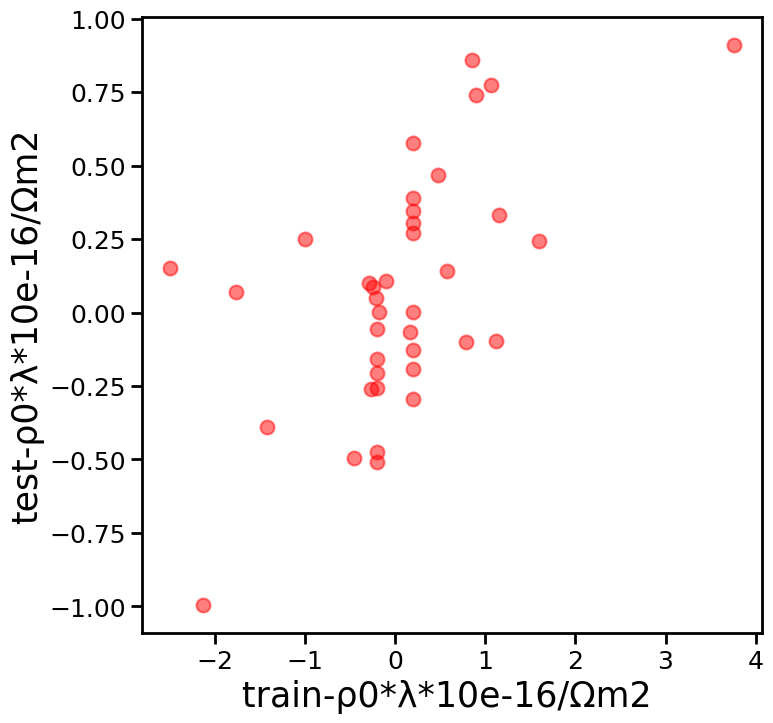

(583,)
预测结果: [ 0.03400332  0.92018898  0.57661799  1.51784268  0.87832362  0.28447702
 -0.04527158 -0.02835212  0.58624874 -0.22477777 -0.04131094 -0.11013341
  0.73231391  0.02536951  0.18924445  0.85196274  0.52307815  0.44978724
 -0.07814159 -0.23251333 -0.02399783  0.29596304  0.22610492  0.10372066
  0.60848661  0.04899452  1.23682798  0.70932043  0.28469602  0.08307695
  0.083366    0.56308497 -0.0903964   0.01214778  0.00476564  0.63536212
  0.1213248   0.28329342  0.8704422   0.60628567  0.28809421 -0.02413504
 -0.03217305 -0.00263646  0.48442277  0.58037142  0.09092612  0.32477283
  1.22408858  0.20544062  0.11917927  0.17175486  0.51882027  0.40265678
  1.01181836  0.62513755  0.32001235  0.1780763   0.17225524  0.55101197
  0.05199395  0.11926675  0.12340716  0.60969732  0.2178634   0.3607847
  0.85451775  0.63470545  0.27972043  0.0931124   0.14014201  0.20467171
  0.57204127  0.18198886  0.35458021  1.09338491  0.21018124  0.23904488
  0.50377156  0.41971182  0.21525377  0

In [11]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
import time
import joblib
from scipy.stats import pearsonr
from modules import *
import sys
import math
import numpy as np
import matplotlib.pyplot as plt


File = '../data.4/error-1'
X,y= sub_data(File)
X,y= pre_data(X,y)
X=X[:38,:]
y=y[:38]
# X=np.delete(X,[6],axis= 1)
print(X.shape)
print(y.shape)



krr = KernelRidge(kernel='rbf', gamma=0.01, alpha=0.015)
krr.fit(X, y)
y_pre=krr.predict(X)


# 绘制散点图 画布大小以及坐标轴字体大小以及粗细
plt.figure(figsize=(8,8))
ax=plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
#plt.scatter(y, y_pre,s = 100,c='b', alpha=0.5)  # 绘制所有数据点
plt.scatter(y,y_pre,s= 100, color='r',alpha= 0.5)  
# plt.xlim(2,10)
# plt.ylim(2,10)
plt.xlabel('train-ρ0*λ*10e-16/Ωm2 ',fontsize=25)
plt.ylabel('test-ρ0*λ*10e-16/Ωm2',fontsize=25)
plt.show()


File = '../data.4/error-1'
X1,y1= sub_data(File)
X1,y1= pre_data(X1,y1)
X1=X1[38:,:]
y1=y1[38:]
# X1=np.delete(X1,[6],axis= 1)



predictions = krr.predict(X1)  
df_predictions = pd.DataFrame(predictions, columns=['Prediction3'])  
df_predictions.to_csv('krr-all.csv', index=False)
print(predictions.shape)
# 打印预测结果
print("预测结果:", predictions)
min_value = np.min(predictions)
max_value = np.max(predictions)
min_index = np.argmin(predictions)
max_index = np.argmax(predictions)
print('min_index:',min_index)
print('min_value:',min_value)
print('max_index:',max_index)
print('max_value:',max_value)

In [3]:
# # 假设你已经训练并保存了模型
# # 加载模型
# from sklearn.metrics import mean_absolute_error
# from sklearn.metrics import mean_squared_error
# from sklearn.model_selection import RepeatedKFold
# from sklearn.feature_selection import SelectKBest
# from sklearn.kernel_ridge import KernelRidge
# from sklearn.model_selection import GridSearchCV
# from scipy.stats import pearsonr
# from modules import *
# from sklearn.svm import SVR
# from sklearn.decomposition import PCA
# import joblib
# import sys
# import math
# import numpy as np
# import matplotlib.pyplot as plt
# import modules
# from sklearn.kernel_ridge import KernelRidge



# # 准备新数据

# File = '../data.3/em2.0'
# X1,y1= sub_data(File)
# X1,y1= pre_data(X1,y1)
# X1=X1[53:,:]
# y1=y1[53:]
# # X1=np.delete(X1,[0,2,5,6],axis= 1)
# print(X1.shape)
# print(y1.shape)

# # 加载模型
# loaded_model = joblib.load('model.krr_fps')

# # 进行预测
# predictions = loaded_model.predict(X1)
# # 使用pandas创建DataFrame
# df_predictions = pd.DataFrame(predictions, columns=['Prediction3'])

# # 将DataFrame保存为CSV文件
# df_predictions.to_csv('krr_fps.4.csv', index=False)

# print(predictions.shape)
# # 打印预测结果
# print("预测结果:", predictions)
# # 寻找矩阵中的最小值
# min_value = np.min(predictions)

# # 寻找矩阵中的最大值
# max_value = np.max(predictions)

# print("最小值:", min_value)
# print("最大值:", max_value)
# max_index = np.argmax(predictions)
# min_index = np.argmin(predictions)
# print("最小值的位置:", min_index)
# print("最大值的位置:", max_index)


In [4]:
# def count_values_in_intervals(values, intervals):
#     """
#     统计每个区间内的数值个数。

#     :param values: list, 包含数值的列表。
#     :param intervals: list of tuples, 区间列表，每个区间是一个元组，如[(a, b), (c, d)]。
#     :return: list, 每个区间内数值的个数。
#     """
#     counts = []
#     for interval in intervals:
#         start, end = interval
#         count = sum(1 for value in values if start <= value < end)
#         counts.append(count)
#     return counts


# intervals = [(3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10)]
# result = count_values_in_intervals(predictions, intervals)
# print(result)  # 输出：[3, 3, 3]